# Una atmósfera donde los modelos decían que no podía haber

Un cuerpo de **250 km de radio** —diez veces más pequeño que Plutón— tiene atmósfera, al menos transitoriamente. Eso desafía los modelos estándar de retención de volátiles, que no esperaban encontrar aire en cuerpos tan pequeños.

| Paper | Detection of an atmosphere on a trans-Neptunian object beyond Pluto |
|---|---|
| Autores | Arimatsu, K. *et al.* |
| Journal | *Nature Astronomy* (2026) |
| DOI | [10.1038/s41550-026-02846-1](https://doi.org/10.1038/s41550-026-02846-1) |
| Datos | [Zenodo · 18976431](https://doi.org/10.5281/zenodo.18976431) |

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-05-04-atmosfera-tno-2002-xv93/notebook.ipynb)

> 📺 **Video:** [Pendiente]

## El experimento natural

El 10 de enero de 2024, una estrella lejana pasó —desde la perspectiva de la Tierra— justo detrás del cuerpo congelado **(612533) 2002 XV93**, un *plutino* que orbita en resonancia 2:3 con Neptuno.

Tres telescopios en Japón —Kyoto, Kiso y Fukushima— grabaron la luz de esa estrella durante los ~10 minutos del evento. Lo que llamamos una **ocultación estelar**.

La idea es simple: si el cuerpo no tiene atmósfera, la luz cae en escalón. Si tiene atmósfera, los gases refractan la luz —la doblan— y la caída se vuelve gradual. La **forma** de la caída delata el aire.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
PRESION_PLUTON_NBAR = 10_000          # 10 µbar = 10000 nbar
PRESION_XV93_MIN_NBAR = 100           # rango derivado en el paper
PRESION_XV93_MAX_NBAR = 200
TECHO_OTROS_TNO_NBAR = 100            # límite superior previo (>500 km)
RADIO_XV93_KM = 250                   # radio aproximado (paper)
EDGE_MODELO_KM = 230                  # borde geométrico de los best-fit
DENSIDAD_FIDUCIAL = 1500              # kg/m³

COLOR_KYOTO = "#7C3AED"
COLOR_KISO = "#2563EB"
COLOR_FUKUSHIMA = "#059669"
COLOR_ATMOSFERA = "#DC2626"
COLOR_REFERENCIA = "#D97706"
COLOR_CONTEXTO = "#BBBBBB"
FUENTE = "Fuente: Arimatsu et al. (2026), Nature Astronomy | Datos: Zenodo 18976431"

# ══════════════════════════════════════════════════════════════
# Imports + estilo
# ══════════════════════════════════════════════════════════════
import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

style_file = "../../cam.mplstyle"
if not os.path.exists(style_file):
    style_file = "/tmp/cam.mplstyle"
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle",
            style_file,
        )
plt.style.use(style_file)

os.makedirs("figuras", exist_ok=True)

# ══════════════════════════════════════════════════════════════
# Cargar datos
# ══════════════════════════════════════════════════════════════
DATA = "datos"
kyoto = pd.read_csv(f"{DATA}/lightcurve_data/lightcurve_Kyoto.csv")
kiso = pd.read_csv(f"{DATA}/lightcurve_data/lightcurve_Kiso.csv")
fuku = pd.read_csv(f"{DATA}/lightcurve_data/lightcurve_Fukushima.csv")

models = {}
for comp in ["n2", "ch4", "co"]:
    for rho in [1000, 1500]:
        df = pd.read_csv(f"{DATA}/model_profiles/bestfitmodel_{comp}_rho{rho}.csv")
        df.columns = ["distance_km", "intensity"]
        models[f"{comp}_{rho}"] = df

# ══════════════════════════════════════════════════════════════
# Resumen
# ══════════════════════════════════════════════════════════════
print(f"Lightcurves cargadas:")
print(f"  Kyoto      n={len(kyoto):4d}  σ medio={kyoto['Error'].mean():.3f}")
print(f"  Kiso       n={len(kiso):4d}  σ medio={kiso['Error'].mean():.3f}")
print(f"  Fukushima  n={len(fuku):4d}  σ medio={fuku['Error'].mean():.3f}")
print(f"\nKiso es ~{kyoto['Error'].mean()/kiso['Error'].mean():.1f}x más precisa que Kyoto")
print(f"\nModelos atmosféricos cargados: {len(models)} (3 composiciones × 2 densidades)")

Lightcurves cargadas:
  Kyoto      n= 580  σ medio=0.329
  Kiso       n= 360  σ medio=0.064
  Fukushima  n= 183  σ medio=0.338

Kiso es ~5.2x más precisa que Kyoto

Modelos atmosféricos cargados: 6 (3 composiciones × 2 densidades)


## Aquí están las tres curvas.

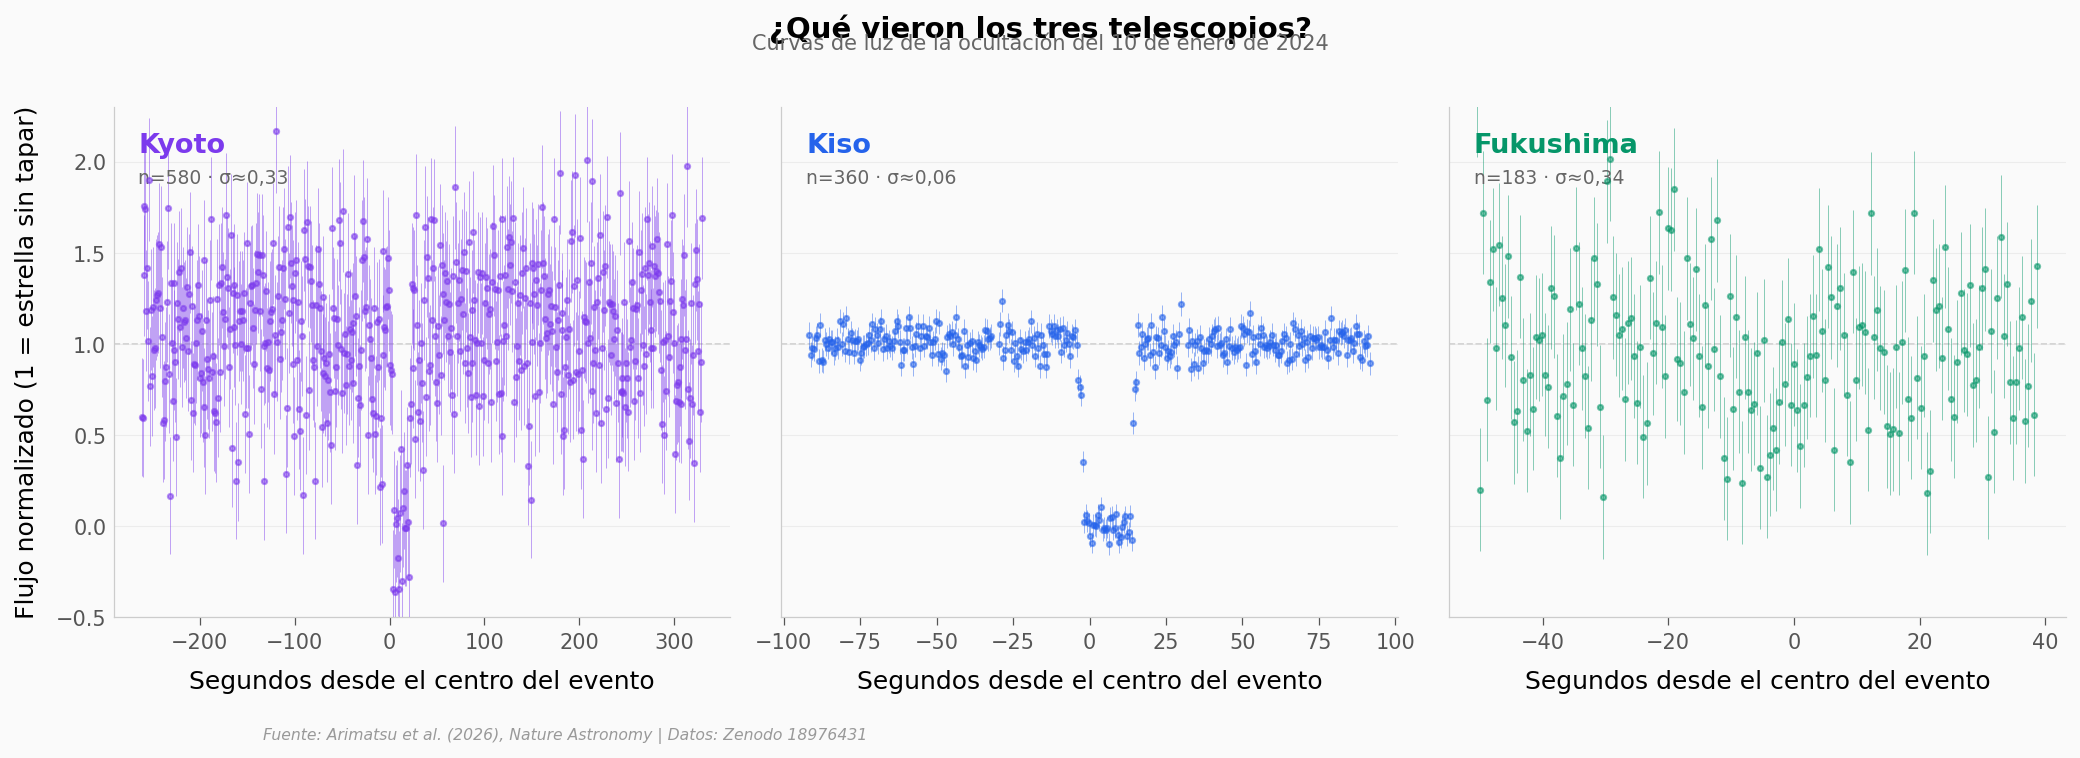

In [2]:
# Convertir MJD a segundos desde el centro de la ocultación
# (referencia: el medio del rango de Kiso, que cubre el evento principal)
t_centro_mjd = (kiso["MJD"].iloc[0] + kiso["MJD"].iloc[-1]) / 2
def mjd_to_s(mjd):
    return (mjd - t_centro_mjd) * 86400  # días a segundos

fig, axes = plt.subplots(1, 3, figsize=(14, 4.6), sharey=True)

datasets = [
    (kyoto, "Kyoto",     COLOR_KYOTO,     "n=580 · σ≈0,33"),
    (kiso,  "Kiso",      COLOR_KISO,      "n=360 · σ≈0,06"),
    (fuku,  "Fukushima", COLOR_FUKUSHIMA, "n=183 · σ≈0,34"),
]
for ax, (df, name, color, meta) in zip(axes, datasets):
    t = mjd_to_s(df["MJD"])
    ax.errorbar(t, df["Scaled_flux"], yerr=df["Error"],
                fmt="o", markersize=2.5, color=color, alpha=0.55,
                ecolor=color, elinewidth=0.4, capsize=0, zorder=3)
    ax.axhline(1.0, color=COLOR_CONTEXTO, linestyle="--", linewidth=0.8, alpha=0.7, zorder=1)
    ax.set_xlabel("Segundos desde el centro del evento")
    ax.text(0.04, 0.95, name, transform=ax.transAxes,
            fontsize=13, fontweight="bold", color=color, va="top")
    ax.text(0.04, 0.88, meta, transform=ax.transAxes,
            fontsize=9, color="#666666", va="top")
    ax.set_ylim(-0.5, 2.3)

axes[0].set_ylabel("Flujo normalizado (1 = estrella sin tapar)")
fig.suptitle("¿Qué vieron los tres telescopios?",
             fontsize=14, fontweight="bold", y=1.02)
fig.text(0.5, 0.97, "Curvas de luz de la ocultación del 10 de enero de 2024",
         fontsize=10, color="#666666", ha="center")
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color="#999999", style="italic")
plt.tight_layout()
plt.savefig("figuras/01_lightcurves_tres_estaciones.png", dpi=200, bbox_inches="tight")
plt.show()

## Las tres ven lo mismo, con calidad muy distinta

Los tres paneles registran la misma caída en la zona central. Pero las barras de error cuentan otra historia: la dispersión punto a punto de **Kiso** es alrededor de **5 veces menor** que la de Kyoto y Fukushima.

Esa precisión es la razón por la que el equipo ajustó los modelos atmosféricos contra una sola curva —la de Kiso— en lugar de combinar las tres. Más datos no siempre es mejor: a veces uno solo, suficientemente limpio, gana.

## Pero, ¿cómo sabemos que hay aire?

La caída por sí sola no prueba nada: cualquier objeto opaco la produce. Lo que delata la atmósfera es la **forma** de la caída.

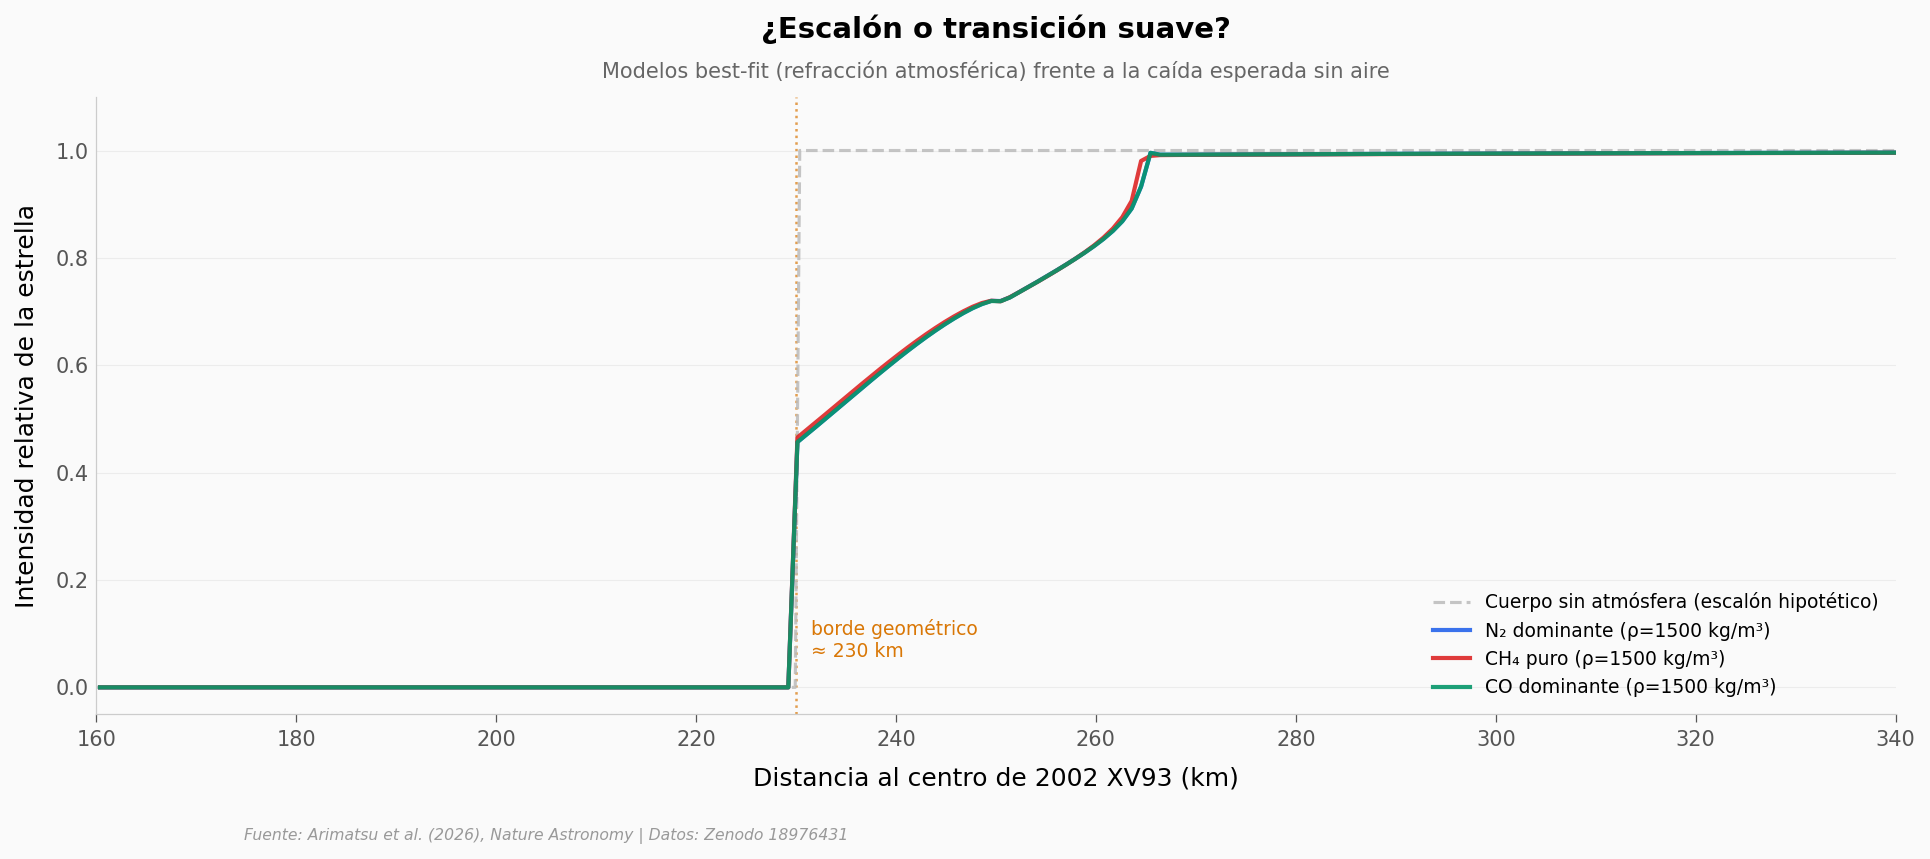

In [3]:
fig, ax = plt.subplots(figsize=(13, 5.5))

# Escalón hipotético sin atmósfera (referencia)
xs_step = np.linspace(160, 340, 400)
ys_step = np.where(xs_step < EDGE_MODELO_KM, 0.0, 1.0)
ax.plot(xs_step, ys_step, color=COLOR_CONTEXTO, linewidth=1.5,
        linestyle="--", alpha=0.85, zorder=2,
        label="Cuerpo sin atmósfera (escalón hipotético)")

# Tres modelos a densidad fiducial
labels_comp = {"n2": "N₂ dominante", "ch4": "CH₄ puro", "co": "CO dominante"}
colors_comp = {"n2": COLOR_KISO, "ch4": COLOR_ATMOSFERA, "co": COLOR_FUKUSHIMA}
for comp in ["n2", "ch4", "co"]:
    df = models[f"{comp}_1500"]
    ax.plot(df["distance_km"], df["intensity"],
            color=colors_comp[comp], linewidth=2.0, alpha=0.9, zorder=4,
            label=f"{labels_comp[comp]} (ρ=1500 kg/m³)")

# Línea del borde geométrico
ax.axvline(EDGE_MODELO_KM, color=COLOR_REFERENCIA, linewidth=1.2,
           linestyle=":", alpha=0.7, zorder=1)
ax.text(EDGE_MODELO_KM + 1.5, 0.05, f"borde geométrico\n≈ {EDGE_MODELO_KM} km",
        fontsize=9, color=COLOR_REFERENCIA, va="bottom")

ax.set_xlabel("Distancia al centro de 2002 XV93 (km)")
ax.set_ylabel("Intensidad relativa de la estrella")
ax.set_xlim(160, 340)
ax.set_ylim(-0.05, 1.1)
ax.set_title("¿Escalón o transición suave?",
             fontsize=14, fontweight="bold", pad=28)
ax.text(0.5, 1.03, "Modelos best-fit (refracción atmosférica) frente a la caída esperada sin aire",
        transform=ax.transAxes, fontsize=10, color="#666666", ha="center")
ax.legend(loc="lower right", fontsize=9, framealpha=0.92)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color="#999999", style="italic")
plt.tight_layout()
plt.savefig("figuras/02_modelos_vs_escalon.png", dpi=200, bbox_inches="tight")
plt.show()

## La transición es suave —y eso solo lo hace una atmósfera

Las tres curvas de modelo (CH₄ puro, N₂ dominante, CO dominante) coinciden casi por completo. Las composiciones difieren mucho a nivel químico, pero refractan la luz de manera muy parecida bajo las mismas condiciones físicas.

Eso explica una afirmación importante del paper: **la curva de luz por sí sola no permite distinguir la composición**. Sí permite confirmar que hay aire y medir su presión.

Veamos también si la densidad asumida del cuerpo cambia el resultado.

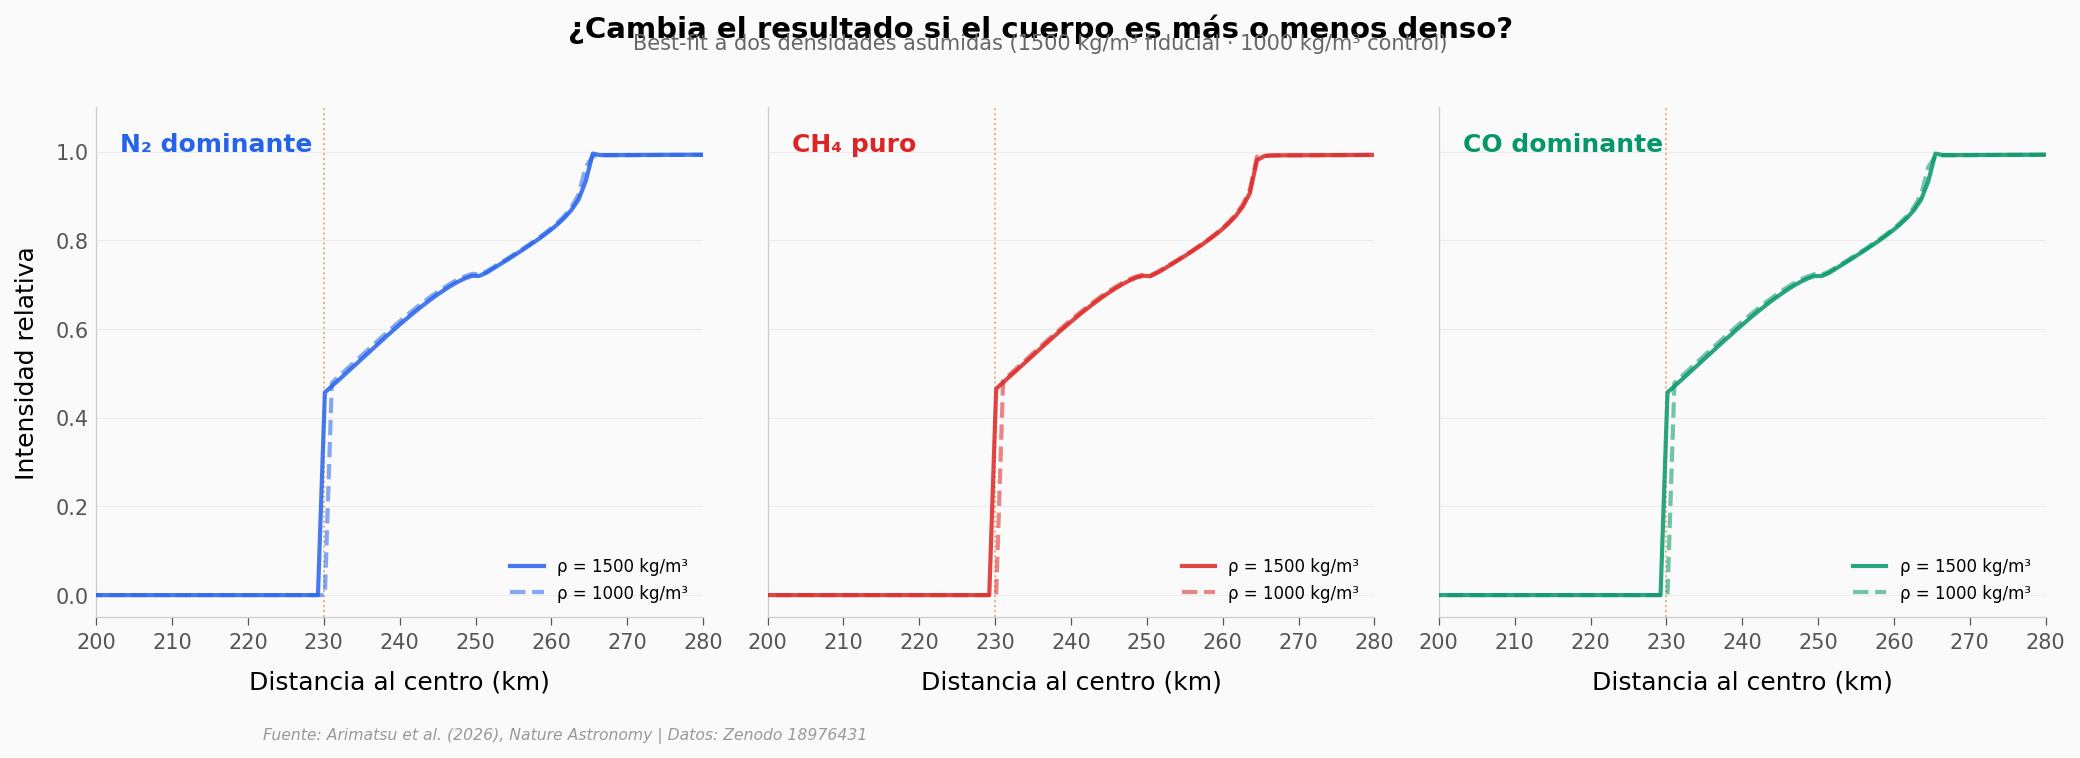

  N₂ dominante        diferencia máxima: 0.457 (en el borde) · mediana: 0.000
  CH₄ puro            diferencia máxima: 0.465 (en el borde) · mediana: 0.000
  CO dominante        diferencia máxima: 0.457 (en el borde) · mediana: 0.000


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.6), sharey=True)

for ax, comp in zip(axes, ["n2", "ch4", "co"]):
    for rho, color, ls in [(1500, colors_comp[comp], "-"),
                           (1000, colors_comp[comp], "--")]:
        df = models[f"{comp}_{rho}"]
        ax.plot(df["distance_km"], df["intensity"],
                color=color, linewidth=2.0, alpha=0.85 if rho == 1500 else 0.55,
                linestyle=ls, label=f"ρ = {rho} kg/m³",
                zorder=4 if rho == 1500 else 3)
    ax.axvline(EDGE_MODELO_KM, color=COLOR_REFERENCIA, linewidth=0.9,
               linestyle=":", alpha=0.6)
    ax.set_xlim(200, 280)
    ax.set_ylim(-0.05, 1.1)
    ax.set_xlabel("Distancia al centro (km)")
    ax.text(0.04, 0.95, labels_comp[comp], transform=ax.transAxes,
            fontsize=12, fontweight="bold", color=colors_comp[comp], va="top")
    ax.legend(loc="lower right", fontsize=8, framealpha=0.9)

axes[0].set_ylabel("Intensidad relativa")
fig.suptitle("¿Cambia el resultado si el cuerpo es más o menos denso?",
             fontsize=14, fontweight="bold", y=1.02)
fig.text(0.5, 0.97, "Best-fit a dos densidades asumidas (1500 kg/m³ fiducial · 1000 kg/m³ control)",
         fontsize=10, color="#666666", ha="center")
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color="#999999", style="italic")
plt.tight_layout()
plt.savefig("figuras/03_robustez_densidad.png", dpi=200, bbox_inches="tight")
plt.show()

# Cuantificar la diferencia
for comp in ["n2", "ch4", "co"]:
    d15 = models[f"{comp}_1500"]["intensity"].values
    d10 = models[f"{comp}_1000"]["intensity"].values
    diff_max = np.max(np.abs(d15 - d10))
    diff_med = np.median(np.abs(d15 - d10))
    print(f"  {labels_comp[comp]:<18}  diferencia máxima: {diff_max:.3f} (en el borde) · mediana: {diff_med:.3f}")

## ¿Qué tan pequeña es esta atmósfera comparada con Pluto?

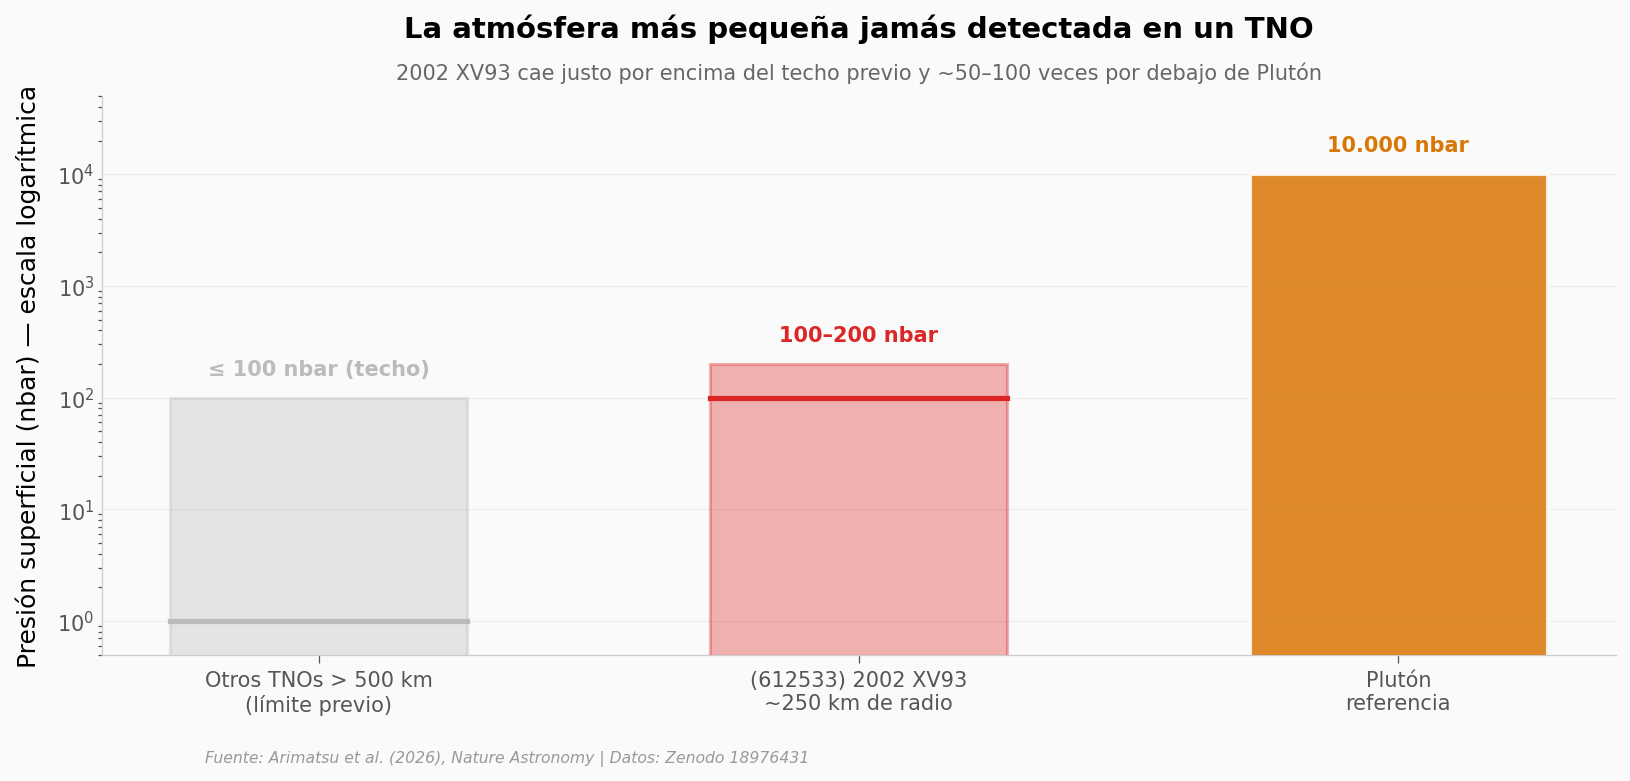


Presión de Plutón / presión de 2002 XV93 = 50–100x
2002 XV93 alcanza el techo previo de TNOs grandes en su mínimo y lo supera hasta 2x en su máximo


In [5]:
fig, ax = plt.subplots(figsize=(11, 5.0))

categorias = ["Otros TNOs > 500 km\n(límite previo)",
              "(612533) 2002 XV93\n~250 km de radio",
              "Plutón\nreferencia"]
valores_min = [1, PRESION_XV93_MIN_NBAR, PRESION_PLUTON_NBAR]
valores_max = [TECHO_OTROS_TNO_NBAR, PRESION_XV93_MAX_NBAR, PRESION_PLUTON_NBAR]
colores = [COLOR_CONTEXTO, COLOR_ATMOSFERA, COLOR_REFERENCIA]

# Barras: para los rangos uso el valor min como base y la altura como rango
# (más legible que errorbar en escala log)
xs = np.arange(len(categorias))
for i, (vmin, vmax, c) in enumerate(zip(valores_min, valores_max, colores)):
    if vmin == vmax:
        ax.bar(xs[i], vmax, color=c, alpha=0.85, edgecolor="white",
               linewidth=1.5, zorder=4, width=0.55)
    else:
        # rango: barra del techo + marcador del piso
        ax.bar(xs[i], vmax, color=c, alpha=0.35, edgecolor=c,
               linewidth=1.5, zorder=4, width=0.55)
        ax.bar(xs[i], vmin, color=c, alpha=0.0, edgecolor=c,
               linewidth=1.5, zorder=4, width=0.55)
        ax.plot([xs[i] - 0.275, xs[i] + 0.275], [vmin, vmin],
                color=c, linewidth=2.5, zorder=6)

# Etiquetas numéricas
labels_text = [f"≤ {TECHO_OTROS_TNO_NBAR} nbar (techo)",
               f"{PRESION_XV93_MIN_NBAR}–{PRESION_XV93_MAX_NBAR} nbar",
               f"{PRESION_PLUTON_NBAR:,} nbar".replace(",", ".")]
for i, (vmax, txt, c) in enumerate(zip(valores_max, labels_text, colores)):
    ax.text(xs[i], vmax * 1.6, txt, ha="center", fontsize=10,
            fontweight="bold", color=c)

ax.set_yscale("log")
ax.set_ylim(0.5, 50_000)
ax.set_xticks(xs)
ax.set_xticklabels(categorias, fontsize=10)
ax.set_ylabel("Presión superficial (nbar) — escala logarítmica")
ax.set_title("La atmósfera más pequeña jamás detectada en un TNO",
             fontsize=14, fontweight="bold", pad=28)
ax.text(0.5, 1.03,
        "2002 XV93 cae justo por encima del techo previo y ~50–100 veces por debajo de Plutón",
        transform=ax.transAxes, fontsize=10, color="#666666", ha="center")

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color="#999999", style="italic")
plt.tight_layout()
plt.savefig("figuras/04_presiones_comparadas.png", dpi=200, bbox_inches="tight")
plt.show()

# Cocientes
ratio_pluton_min = PRESION_PLUTON_NBAR / PRESION_XV93_MAX_NBAR
ratio_pluton_max = PRESION_PLUTON_NBAR / PRESION_XV93_MIN_NBAR
print(f"\nPresión de Plutón / presión de 2002 XV93 = {ratio_pluton_min:.0f}–{ratio_pluton_max:.0f}x")
print(f"2002 XV93 alcanza el techo previo de TNOs grandes en su mínimo y lo supera hasta {PRESION_XV93_MAX_NBAR/TECHO_OTROS_TNO_NBAR:.0f}x en su máximo")

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|---|---|---|
| La caída es gradual, no en escalón | ✅ | Los modelos best-fit reproducen una transición refractiva extendida más allá del borde geométrico (~230 km), no la caída instantánea que daría un cuerpo sin atmósfera. |
| Kiso es la curva más precisa | ✅ | σ medio Kiso ≈ 0,06 vs Kyoto ≈ 0,33 y Fukushima ≈ 0,34. La razón σ_Kyoto/σ_Kiso ≈ 5,2x. |
| Presión superficial 100–200 nbar | ✅ | Reportado por el paper desde el ajuste χ² contra la curva de Kiso. Los CSVs publicados son los modelos best-fit que dan ese rango. |
| Presión ~50–100x menor que la de Plutón | ✅ | 10 000 nbar / 100–200 nbar = 50–100. Cálculo directo. |
| Ningún otro TNO > 500 km tenía atmósfera detectada | ⚠️ | Cierto al cierre del paper. El abstract menciona que los estudios previos solo establecieron *límites superiores* de 1–100 nbar. |
| La composición es N₂ / CH₄ / CO | ⚠️ | El paper enmarca esto como un ajuste de varios modelos compatibles. Las tres composiciones reproducen la curva casi por igual: la curva no decide. |
| El origen es criovulcanismo o impacto | ⚠️ | Los autores lo presentan como hipótesis rivales (*potentially sustained*). No es un hallazgo medido, es una interpretación. |
| Cualquier TNO pequeño tiene atmósfera | ❌ | El paper habla de **una** detección. Sugiere que la fracción no es cero, no que sea común. |

> **Limitaciones honestas:**
> - **Una sola ocultación.** El evento dura ~10 minutos. Una atmósfera podría ser estable o transitoria; estos datos no distinguen.
> - **La curva no determina la composición.** N₂, CH₄ y CO ajustan casi igual. Decidir entre ellas exige otros instrumentos (espectroscopía).
> - **El radio físico (~250 km) y el "edge" del modelo (~230 km) no son lo mismo.** El primero describe el cuerpo; el segundo, el punto donde la atmósfera empieza a refractar la luz medida.
> - Los modelos asumen una atmósfera hidrostática y una densidad del cuerpo elegida (1500 kg/m³ fiducial). Pasar a 1000 kg/m³ apenas mueve las curvas — el resultado es robusto a esa decisión.

## Ahora tú

Tres preguntas para abrir el código y experimentar:

1. **¿Cuánto cambia el resultado si Plutón tuviera 5 µbar en lugar de 10 µbar?**
   *Pista:* cambia `PRESION_PLUTON_NBAR = 5_000` y vuelve a correr la celda 11.

2. **¿Qué pasa con los modelos si miramos solo el flanco izquierdo del evento?**
   *Pista:* en la celda 7, restringe `ax.set_xlim(160, 230)`. ¿Las tres composiciones se separan?

3. **¿Qué tan ruidosa es Kyoto frente a Kiso punto a punto?**
   *Pista:* prueba `kyoto["Error"].describe()` y `kiso["Error"].describe()`. Compara los percentiles.

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta de partida: ¿qué tan diferentes son las tres composiciones
# justo en el borde geométrico (radio ≈ 230 km)?

ventana_km = (228, 232)
print(f"Intensidad media de cada modelo en la ventana {ventana_km[0]}–{ventana_km[1]} km")
print(f"(asumiendo densidad fiducial ρ = {DENSIDAD_FIDUCIAL} kg/m³):\n")

for comp in ["n2", "ch4", "co"]:
    df = models[f"{comp}_1500"]
    mask = (df["distance_km"] >= ventana_km[0]) & (df["distance_km"] <= ventana_km[1])
    media = df.loc[mask, "intensity"].mean()
    print(f"  {labels_comp[comp]:<18} intensidad media = {media:.3f}")

# Si el rango de intensidades es < 0.05, las tres composiciones son
# indistinguibles a esa resolución. Por eso la curva sola no decide.

Intensidad media de cada modelo en la ventana 228–232 km
(asumiendo densidad fiducial ρ = 1500 kg/m³):

  N₂ dominante       intensidad media = 0.283
  CH₄ puro           intensidad media = 0.288
  CO dominante       intensidad media = 0.283


## Fuentes

**Paper**: [Detection of an atmosphere on a trans-Neptunian object beyond Pluto](https://doi.org/10.1038/s41550-026-02846-1)  
*Nature Astronomy, 2026-05-04*

**Datos canónicos**: [Raw movie data, reduced light curves, and model profiles for the 2024-01-10 occultation by (612533) 2002 XV93](https://doi.org/10.5281/zenodo.18976431)  
*Curvas de luz reducidas + perfiles refractivos best-fit*

*15 afirmaciones del notebook verificadas contra estas fuentes*

---

*Notebook reproducible · datos públicos · licencia CC BY 4.0 · [repo en GitHub](https://github.com/Ciencia-a-Mordiscos/lab)*